In [3]:
import torch
torch.cuda.device_count()

0

In [1]:
print("hello")

hello


In [2]:
import pandas as pd
df = pd.read_excel("C:/Users/ngyx/Desktop/Sanwa_forecast_new/data/100T-8 Parameter Data Y2025 to Y2026 Feb for AI Forecast 1.xlsx")


In [3]:
# 1) ensure it's a real datetime (important if it's currently a string)
df[df.columns[0]] = pd.to_datetime(df[df.columns[0]])

# 2) sort oldest -> latest
df = df.sort_values(by=df.columns[0], ascending=True).reset_index(drop=True)

In [ ]:
cols = [
    "injection_time",
    "switchover_position",
    "max_injection_pressure",
    "switchover_pressure",
    "end_of_packing_stroke",
    "plastification_time",
    "nozzle_temperature",
    "barrel_front_temperature",
    "barrel_center_temperature",
    "barrel_rear_temperature",
    "feeder_temperature",
]

df = df[cols]
df


,injection_time,switchover_position,max_injection_pressure,switchover_pressure,end_of_packing_stroke,plastification_time,nozzle_temperature,barrel_front_temperature,barrel_center_temperature,barrel_rear_temperature,feeder_temperature
0,1.69,10.00,136.1,991,1.52,7.37,254.7,255.3,255.3,244.3,59.1
1,1.68,10.00,135.3,1035,2.17,7.36,255.4,255.1,255.2,243.7,59.7
2,1.69,10.00,139.3,1055,2.27,7.45,254.8,255.1,255.1,243.7,59.9
3,1.68,10.00,142.1,1067,1.96,7.52,255.1,255.1,254.9,243.8,59.1
4,1.69,10.00,144.3,1072,2.41,7.74,255.1,255.0,254.8,243.9,59.1
...,...,...,...,...,...,...,...,...,...,...,...
617425,1.83,8.00,160.4,1243,4.11,8.52,255.0,254.9,254.8,244.9,59.8
617426,1.83,7.99,159.8,1245,4.06,8.53,255.0,254.9,254.9,245.0,60.2
617427,1.83,7.99,160.1,1243,4.09,8.59,254.9,255.0,254.8,245.0,59.5
617428,1.83,8.00,160.0,1244,4.15,8.59,255.1,255.1,254.9,245.0,59.0


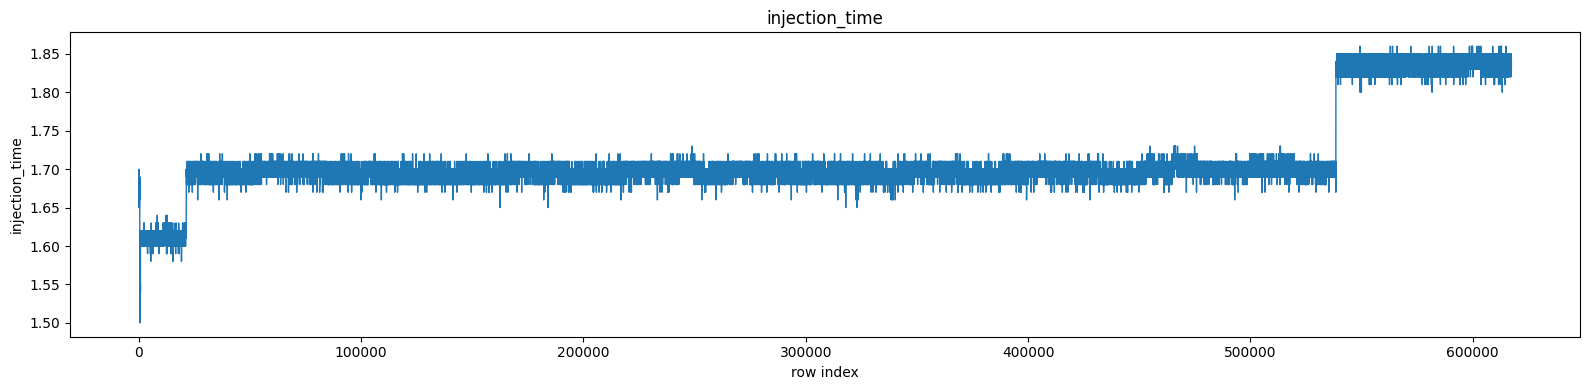

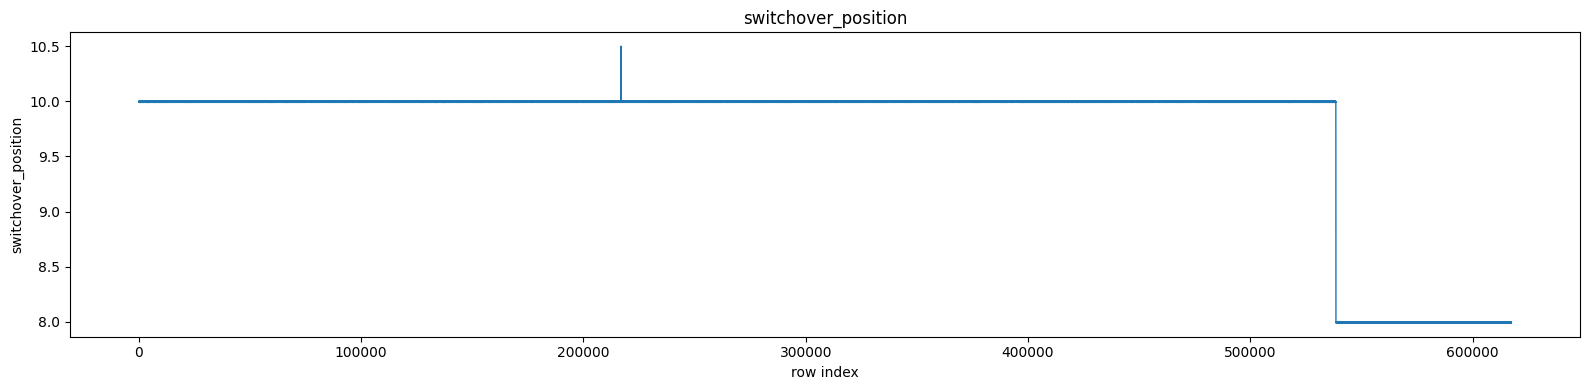

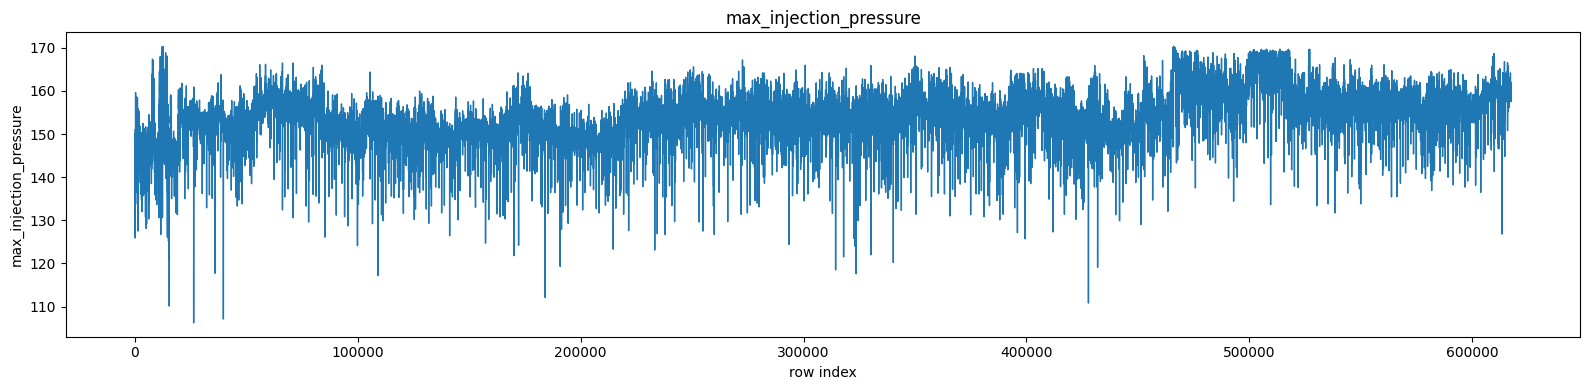

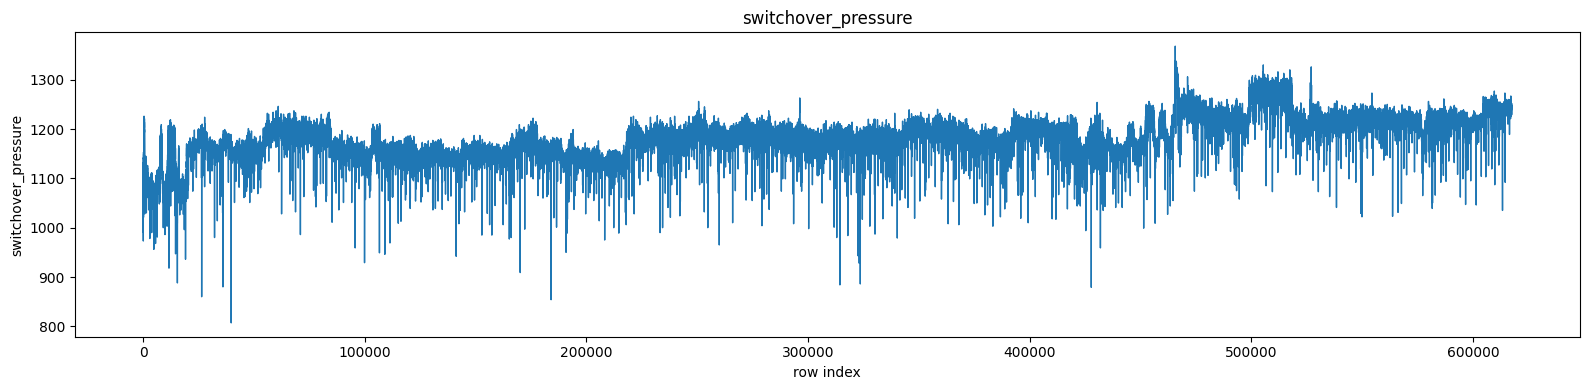

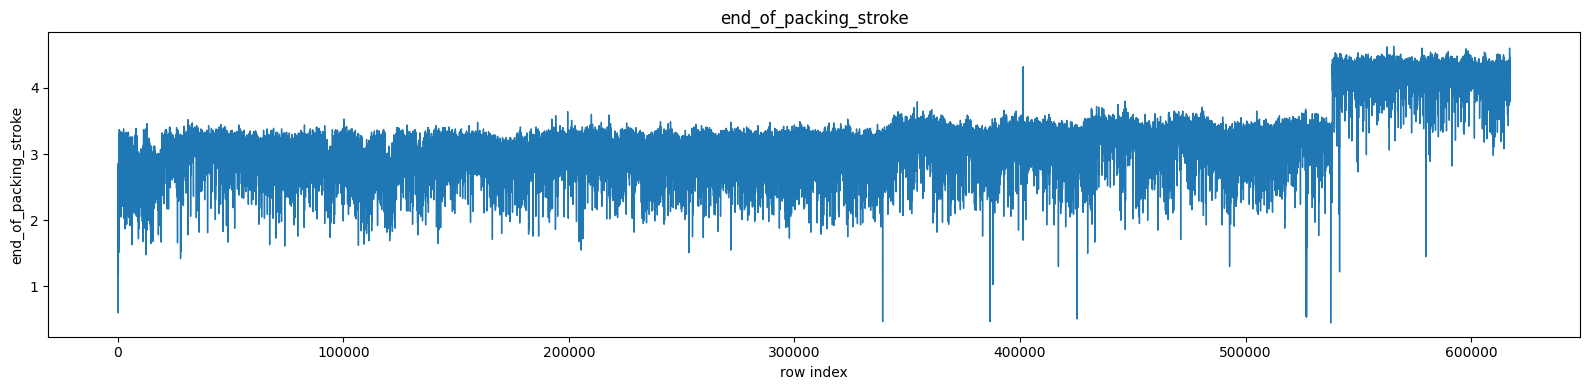

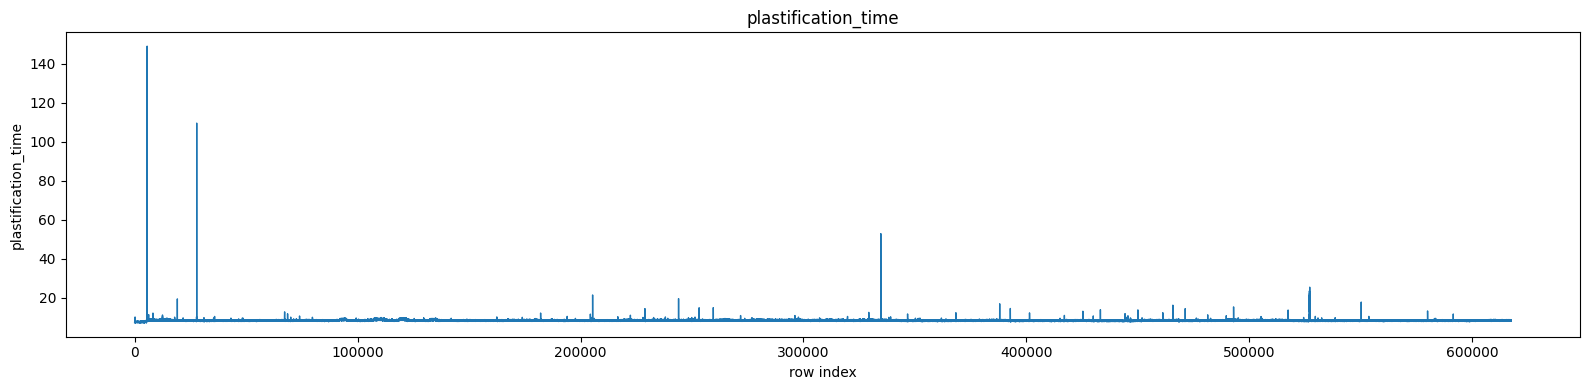

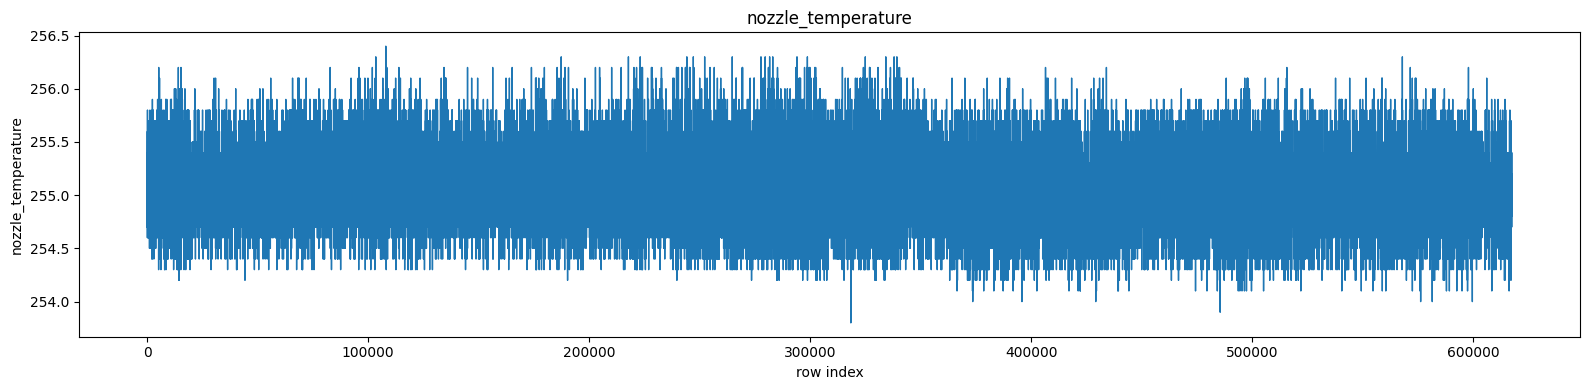

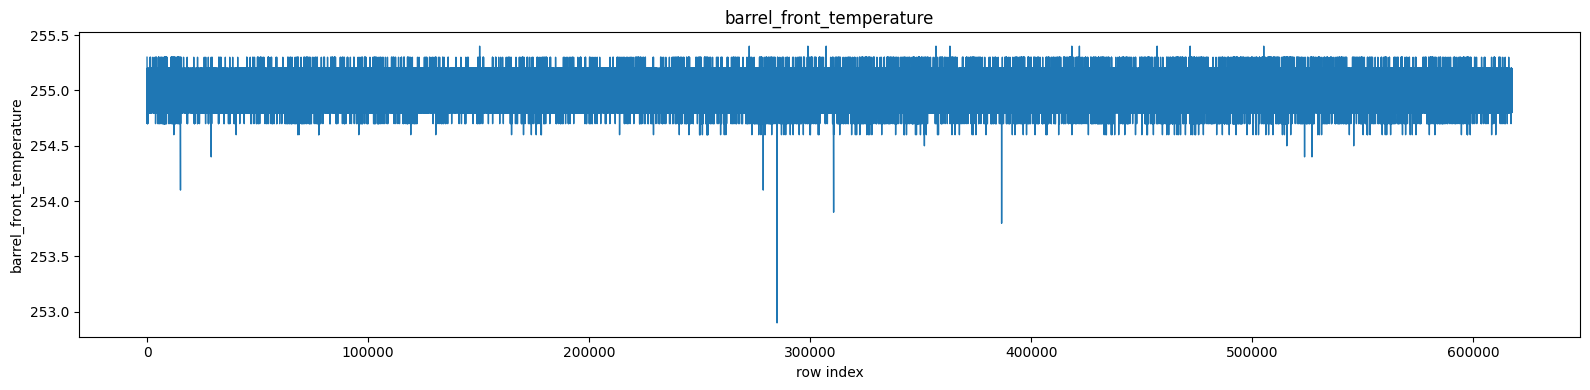

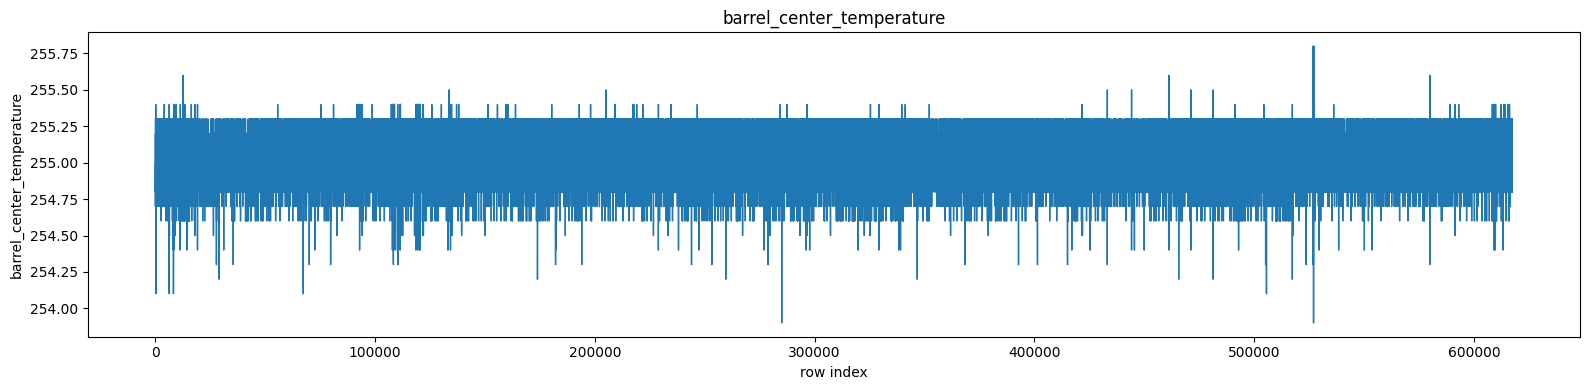

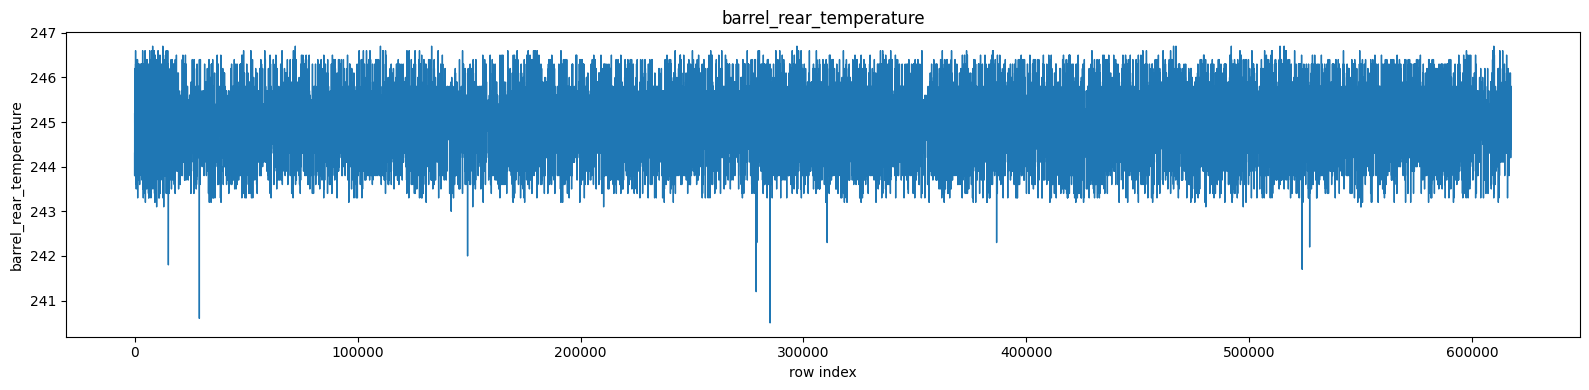

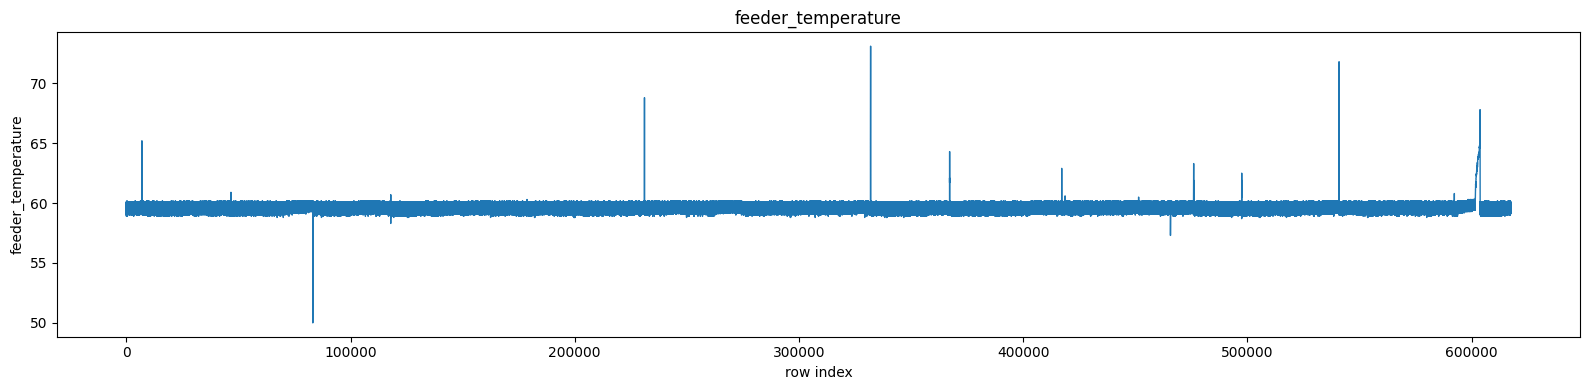

In [5]:
import numpy as np
import matplotlib.pyplot as plt

def plot_each_channel(
    df,
    cols=None,
    time_col=None,      # set to your timestamp column name if you have one (optional)
    max_points=200_000, # downsample target
    show=True,
    save_dir=None,      # e.g. "plots" to save PNGs
):
    if cols is None:
        cols = list(df.columns)

    # x-axis
    if time_col is not None and time_col in df.columns:
        x = df[time_col]
    else:
        x = df.index.to_numpy()

    N = len(df)
    stride = max(1, N // max_points)
    idx = np.arange(0, N, stride)

    x_ds = x.iloc[idx] if hasattr(x, "iloc") else x[idx]

    for c in cols:
        y = df[c].to_numpy()
        y_ds = y[idx]

        plt.figure(figsize=(16, 4))
        plt.plot(x_ds, y_ds, linewidth=1)
        plt.title(c)
        plt.xlabel(time_col if (time_col is not None and time_col in df.columns) else "row index")
        plt.ylabel(c)
        plt.tight_layout()

        if save_dir is not None:
            import os
            os.makedirs(save_dir, exist_ok=True)
            plt.savefig(f"{save_dir}/{c}.png", dpi=150, bbox_inches="tight")

        if show:
            plt.show()
        else:
            plt.close()

# usage
cols = [
    "injection_time",
    "switchover_position",
    "max_injection_pressure",
    "switchover_pressure",
    "end_of_packing_stroke",
    "plastification_time",
    "nozzle_temperature",
    "barrel_front_temperature",
    "barrel_center_temperature",
    "barrel_rear_temperature",
    "feeder_temperature",
]

plot_each_channel(df, cols=cols, max_points=200_000)
# or save:
# plot_each_channel(df, cols=cols, max_points=200_000, save_dir="plots", show=False)

In [46]:
import os
import numpy as np
import pandas as pd
import pyarrow as pa
import pyarrow.parquet as pq

def write_windows_option2_chrono_split(
    df: pd.DataFrame,
    feature_cols,
    out_dir: str,
    window_size: int = 1024,
    horizon: int = 50,
    train_ratio: float = 0.6,
    val_ratio: float = 0.2,
    batch_size: int = 2048,
    compression: str = "zstd",
    sort_by_time_col: str | None = None,
):
    """
    Option 2:
      1) Create ALL windows across full time series (streaming).
      2) Assign each window to train/val/test by where its *label horizon* lies
         w.r.t. raw row cut points. (No random split.)

    Parquet schema:
      - samples: FixedSizeList[float32] length = window_size * C
      - labels : FixedSizeList[float32] length = horizon * C
    """

    os.makedirs(out_dir, exist_ok=True)

    # 0) ensure chronological
    if sort_by_time_col is not None and sort_by_time_col in df.columns:
        df = df.sort_values(sort_by_time_col)

    # 1) keep only needed columns
    df = df.loc[:, feature_cols].dropna()
    arr = df.to_numpy(dtype=np.float32, copy=False)  # (N, C)
    N, C = arr.shape

    if N <= window_size + horizon:
        raise ValueError(f"Need N > window_size + horizon. Got N={N}, ws={window_size}, h={horizon}")

    # Raw-row cut points (chronological)
    cut1 = int(train_ratio * N)
    cut2 = int((train_ratio + val_ratio) * N)

    # Total possible window starts
    num_samples = N - window_size - horizon + 1  # start in [0, num_samples-1]

    X_list_size = window_size * C
    Y_list_size = horizon * C

    # Schema (ONLY samples + labels)
    schema = pa.schema([
        pa.field("samples", pa.list_(pa.float32(), X_list_size)),  # <-- FIX
        pa.field("labels",  pa.list_(pa.float32(), Y_list_size)),  # <-- FIX
    ])

    train_path = os.path.join(out_dir, "train_1p.parquet")
    val_path   = os.path.join(out_dir, "val.parquet")
    test_path  = os.path.join(out_dir, "test.parquet")

    train_writer = pq.ParquetWriter(train_path, schema=schema, compression=compression)
    val_writer   = pq.ParquetWriter(val_path,   schema=schema, compression=compression)
    test_writer  = pq.ParquetWriter(test_path,  schema=schema, compression=compression)

    n_train = n_val = n_test = n_skip = 0

    try:
        for start0 in range(0, num_samples, batch_size):
            end0 = min(start0 + batch_size, num_samples)
            count = end0 - start0

            # Need enough future rows to build X and Y for this batch
            chunk = arr[start0 : end0 + window_size + horizon - 1]  # (count + ws + h - 1, C)

            # X windows: (count, ws, C)
            Xw = np.lib.stride_tricks.sliding_window_view(
                chunk, window_shape=window_size, axis=0
            )[:count]

            # Y windows: (count, h, C) from chunk[ws:]
            Yw = np.lib.stride_tricks.sliding_window_view(
                chunk[window_size:], window_shape=horizon, axis=0
            )[:count]

            starts = np.arange(start0, end0, dtype=np.int64)
            y_start = starts + window_size
            y_end   = y_start + horizon - 1

            # Split masks (labels must be fully inside split segment)
            m_train = (y_end < cut1)
            m_val   = (y_start >= cut1) & (y_end < cut2)
            m_test  = (y_start >= cut2)  # y_end is always < N by construction

            m_keep = m_train | m_val | m_test
            n_skip += int((~m_keep).sum())  # boundary-crossing horizons get skipped

            def write_split(mask, writer):
                nonlocal n_train, n_val, n_test
                if not mask.any():
                    return

                X_sel = Xw[mask]  # (k, ws, C)
                Y_sel = Yw[mask]  # (k, h,  C)
                k = X_sel.shape[0]

                # Flatten with (time, channel) order => length ws*C / h*C
                x_flat = X_sel.reshape(k, X_list_size)
                y_flat = Y_sel.reshape(k, Y_list_size)

                x_arr = pa.FixedSizeListArray.from_arrays(
                    pa.array(x_flat.reshape(-1), type=pa.float32()),
                    list_size=X_list_size,
                )
                y_arr = pa.FixedSizeListArray.from_arrays(
                    pa.array(y_flat.reshape(-1), type=pa.float32()),
                    list_size=Y_list_size,
                )

                tbl = pa.Table.from_arrays([x_arr, y_arr], names=["samples", "labels"])
                writer.write_table(tbl)

                if writer is train_writer:
                    n_train += k
                elif writer is val_writer:
                    n_val += k
                else:
                    n_test += k

            write_split(m_train, train_writer)
            write_split(m_val,   val_writer)
            write_split(m_test,  test_writer)

    finally:
        train_writer.close()
        val_writer.close()
        test_writer.close()

    print("[DONE]")
    print(f"Raw rows: N={N}, C={C}")
    print(f"Cut points (raw idx): train< {cut1}, val< {cut2}, test>= {cut2}")
    print(f"Windows total possible: {num_samples}")
    print(f"Saved train: {n_train}")
    print(f"Saved val  : {n_val}")
    print(f"Saved test : {n_test}")
    print(f"Skipped (boundary-crossing horizons): {n_skip}")
    print("Out dir:", out_dir)
    return train_path, val_path, test_path


# ===== Example usage in your notebook =====
cols = [
    "injection_time",
    "switchover_position",
    "max_injection_pressure",
    "switchover_pressure",
    "end_of_packing_stroke",
    "plastification_time",
    "nozzle_temperature",
    "barrel_front_temperature",
    "barrel_center_temperature",
    "barrel_rear_temperature",
    "feeder_temperature",
]
train_p, val_p, test_p = write_windows_option2_chrono_split(
    df=df,
    feature_cols=cols,
    out_dir="splits_h50_chrono_option2",
    window_size=1024,
    horizon=50,
    train_ratio=0.6,
    val_ratio=0.2,
    batch_size=2048,
    compression="zstd",
    sort_by_time_col=None,  # or your timestamp col if you have one
)

[DONE]
Raw rows: N=617430, C=11
Cut points (raw idx): train< 370458, val< 493944, test>= 493944
Windows total possible: 616357
Saved train: 369385
Saved val  : 123437
Saved test : 123437
Skipped (boundary-crossing horizons): 98
Out dir: splits_h50_chrono_option2


In [2]:
import pandas as pd
df = pd.read_parquet("splits_h50_chrono_option2/test.parquet")
df

,samples,labels
0,"[1.66, 1.66, 1.67, 1.68, 1.67, 1.68, 1.67, 1.6...","[1.7, 1.7, 1.71, 1.69, 1.69, 1.7, 1.7, 1.7, 1...."
1,"[1.66, 1.67, 1.68, 1.67, 1.68, 1.67, 1.67, 1.6...","[1.7, 1.71, 1.69, 1.69, 1.7, 1.7, 1.7, 1.69, 1..."
2,"[1.67, 1.68, 1.67, 1.68, 1.67, 1.67, 1.68, 1.6...","[1.71, 1.69, 1.69, 1.7, 1.7, 1.7, 1.69, 1.7, 1..."
3,"[1.68, 1.67, 1.68, 1.67, 1.67, 1.68, 1.67, 1.6...","[1.69, 1.69, 1.7, 1.7, 1.7, 1.69, 1.7, 1.7, 1...."
4,"[1.67, 1.68, 1.67, 1.67, 1.68, 1.67, 1.67, 1.6...","[1.69, 1.7, 1.7, 1.7, 1.69, 1.7, 1.7, 1.7, 1.7..."
...,...,...
123432,"[1.83, 1.83, 1.83, 1.83, 1.83, 1.83, 1.83, 1.8...","[1.83, 1.83, 1.83, 1.83, 1.83, 1.83, 1.83, 1.8..."
123433,"[1.83, 1.83, 1.83, 1.83, 1.83, 1.83, 1.83, 1.8...","[1.83, 1.83, 1.83, 1.83, 1.83, 1.83, 1.83, 1.8..."
123434,"[1.83, 1.83, 1.83, 1.83, 1.83, 1.83, 1.83, 1.8...","[1.83, 1.83, 1.83, 1.83, 1.83, 1.83, 1.83, 1.8..."
123435,"[1.83, 1.83, 1.83, 1.83, 1.83, 1.83, 1.83, 1.8...","[1.83, 1.83, 1.83, 1.83, 1.83, 1.83, 1.83, 1.8..."


# Prediction and Plot

In [40]:
true[1,6,:]

array([   1.699997 ,    1.699997 ,    1.699997 ,    1.699997 ,
          9.990021 ,    9.990021 ,   10.       ,   10.       ,
         10.       ,  159.2      ,  160.3      ,  159.3      ,
        160.1      ,  160.5      , 1223.       , 1223.       ,
       1220.9999   , 1226.       ,    3.2200012,    3.1100006,
          3.0599976,    3.0499878,    2.9400024,    8.650009 ,
          8.169983 ,    8.529999 ,    8.149994 ,  255.2      ,
        254.8      ,  255.2      ,  254.9      ,  254.9      ,
        255.       ,  254.9      ,  255.       ,  254.7      ,
        255.1      ,  255.       ,  254.9      ,  255.1      ,
        254.9      ,  244.8      ,  245.1      ,  244.9      ,
        245.       ,   59.09999  ,   59.40001  ,   60.09999  ,
         60.       ,   59.199997 ], dtype=float32)

In [41]:
true[0,6,:]

array([   1.699997 ,    1.699997 ,    1.699997 ,    1.699997 ,
          9.990021 ,   10.       ,    9.990021 ,    9.990021 ,
          9.990021 ,  161.5      ,  159.9      ,  160.3      ,
        159.       ,  161.1      , 1224.       , 1222.       ,
       1218.       , 1228.       ,    2.9600067,    3.1799927,
          2.9700012,    3.2700043,    3.2400055,    8.549988 ,
          8.330002 ,    8.589996 ,    8.600006 ,  254.8      ,
        255.       ,  254.9      ,  255.3      ,  255.       ,
        255.       ,  255.       ,  255.2      ,  254.9      ,
        255.2      ,  254.9      ,  254.9      ,  255.       ,
        254.9      ,  245.1      ,  245.       ,  244.8      ,
        244.9      ,   59.40001  ,   59.09999  ,   59.59999  ,
         59.90001  ,   59.300003 ], dtype=float32)

Loaded shapes: pred (123437, 11, 50), true (123437, 11, 50), orig (123437,)


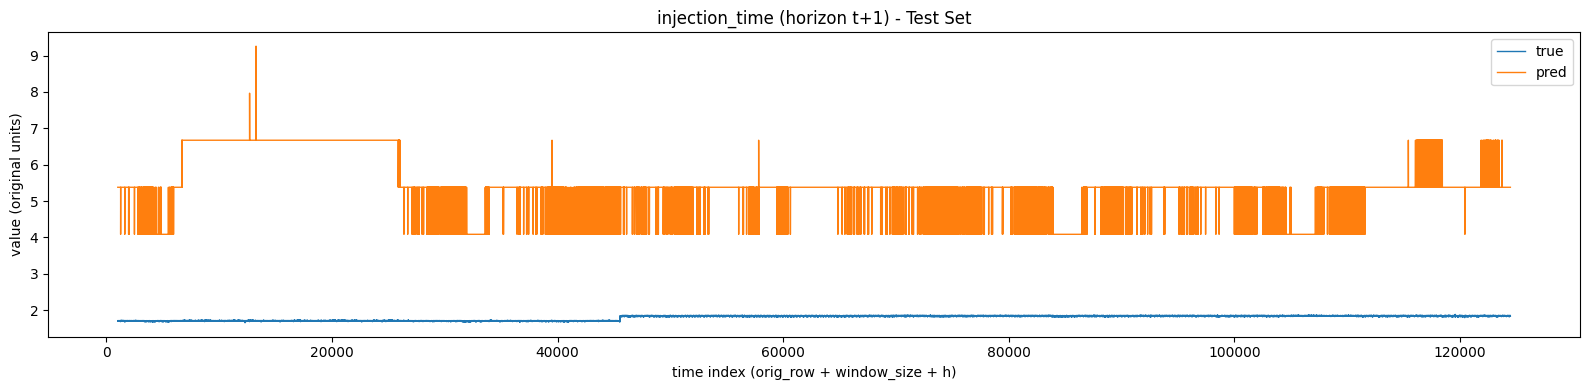

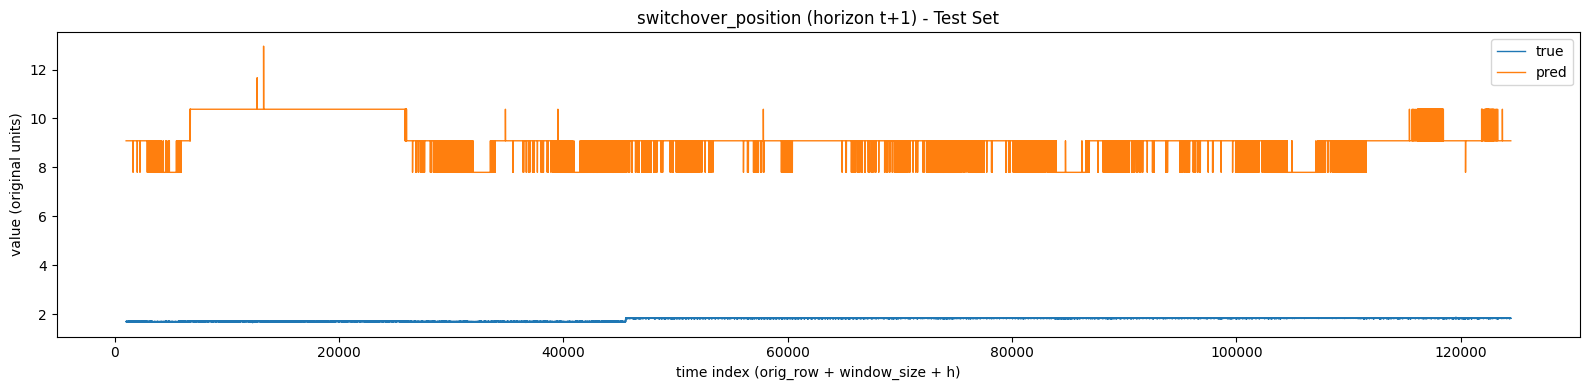

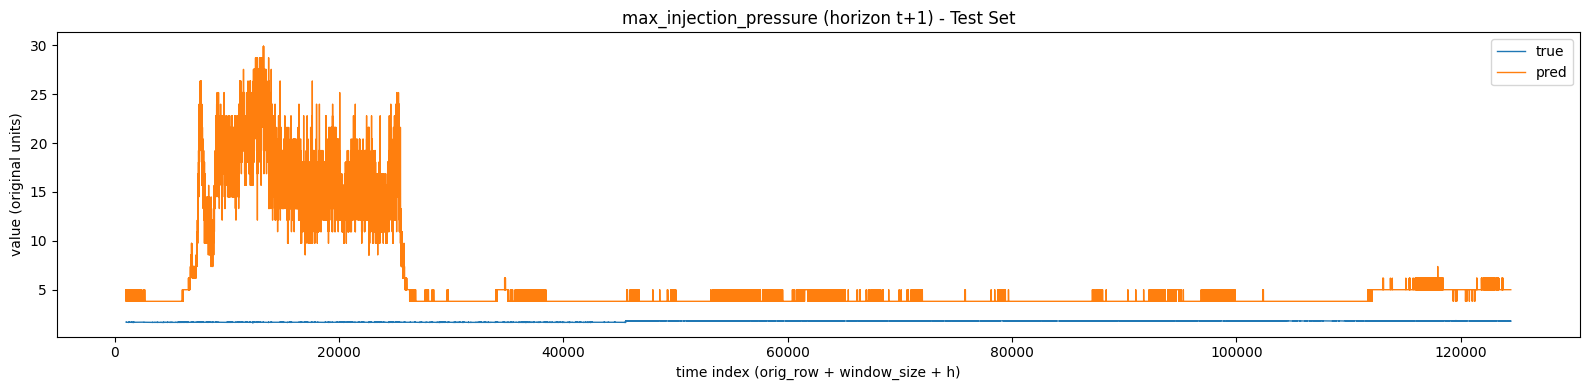

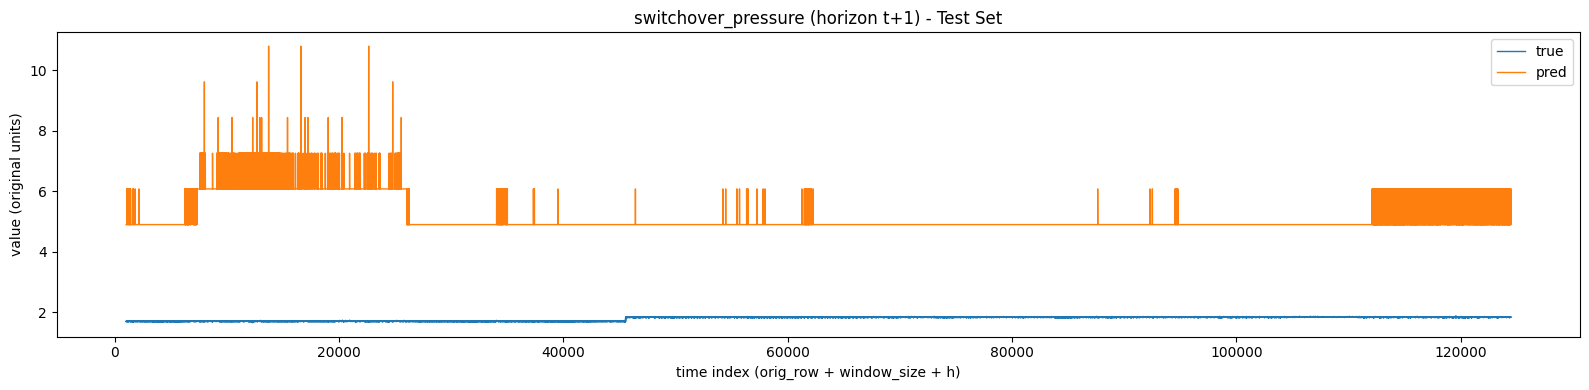

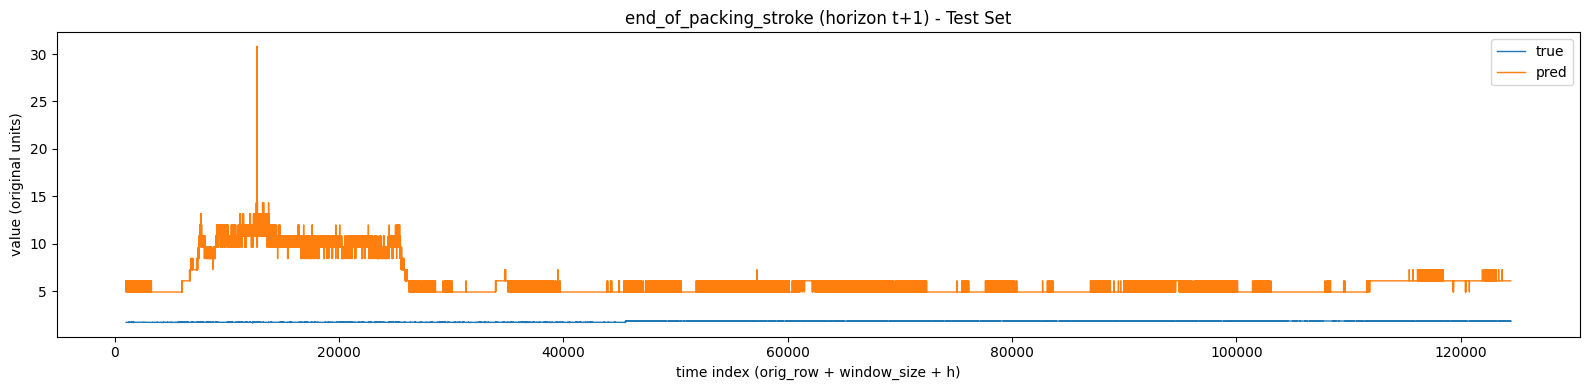

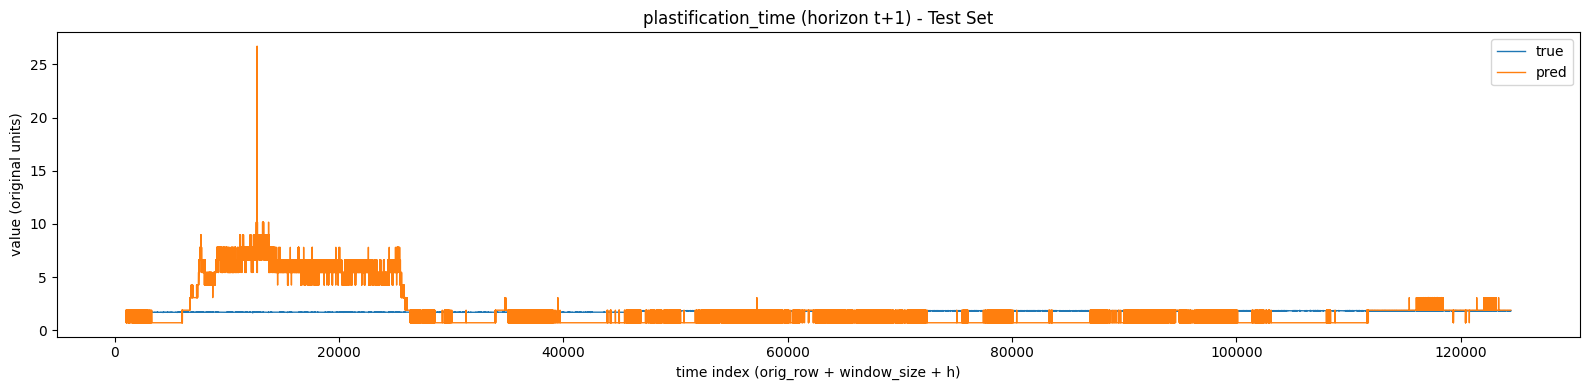

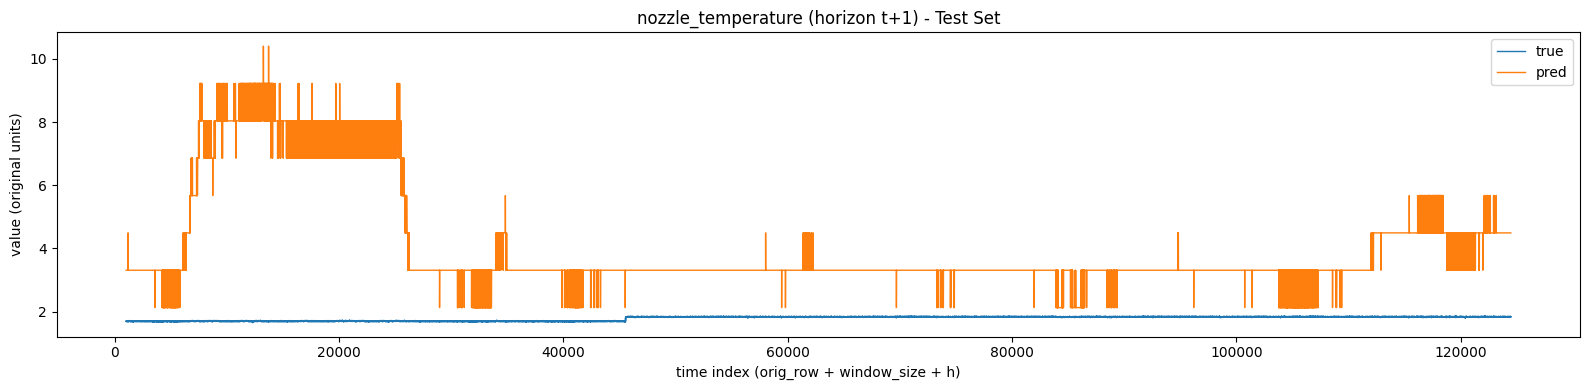

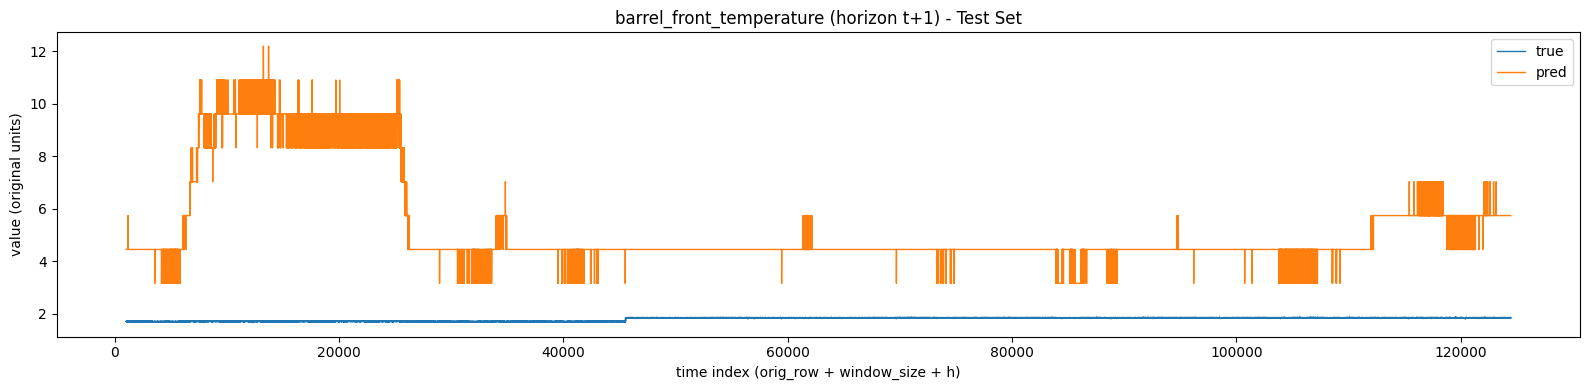

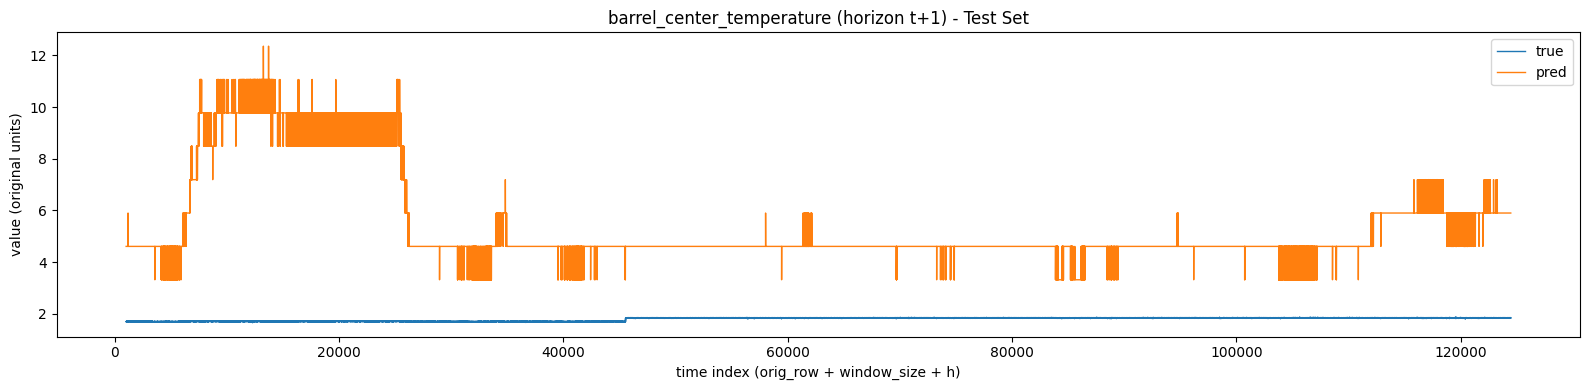

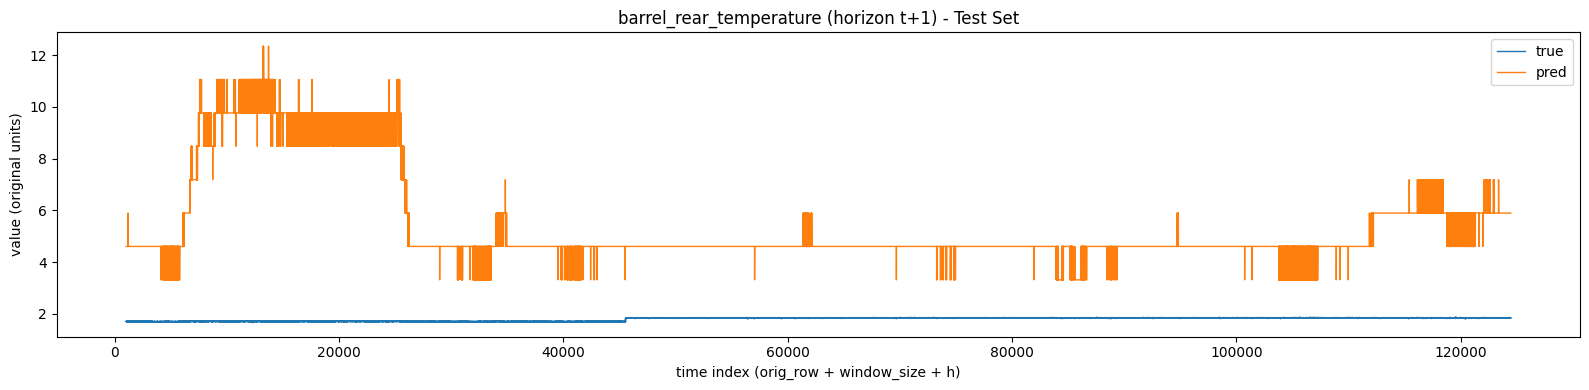

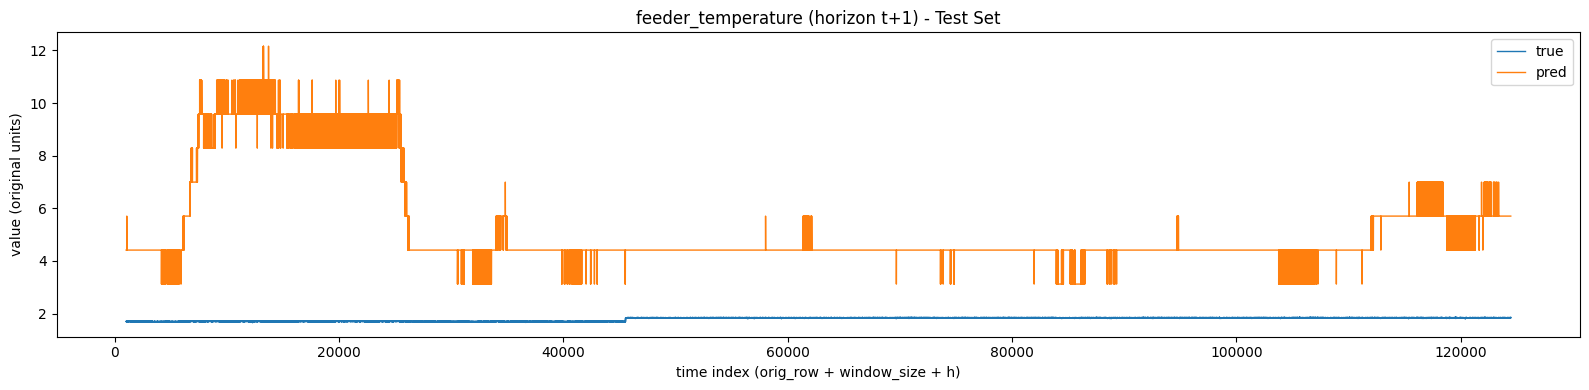

In [47]:
import numpy as np
import matplotlib.pyplot as plt

# Load corrected test predictions and targets (already in original units)
pred = np.load("result/test_preds.npy")  # (N, 11, 50)
true = np.load("result/test_targets.npy")  # (N, 11, 50)
orig = np.load("result/test_orig_row.npy")  # (N,)

# Sort by orig_row for chronological order
order = np.argsort(orig)
pred = pred[order]
true = true[order]
orig = orig[order]

print(f"Loaded shapes: pred {pred.shape}, true {true.shape}, orig {orig.shape}")

# Define columns
cols = [
    "injection_time",
    "switchover_position",
    "max_injection_pressure",
    "switchover_pressure",
    "end_of_packing_stroke",
    "plastification_time",
    "nozzle_temperature",
    "barrel_front_temperature",
    "barrel_center_temperature",
    "barrel_rear_temperature",
    "feeder_temperature",
]

WINDOW_SIZE = 1024
h = 0  # Plot horizon t+1

t = orig + WINDOW_SIZE + h
max_points = 200_000
stride = max(1, len(t) // max_points)
t_ds = t[::stride]

for ch, name in enumerate(cols):
    y_true = true[::stride, ch, h]
    y_pred = pred[::stride, ch, h]

    plt.figure(figsize=(16, 4))
    plt.plot(t_ds, y_true, label="true", linewidth=1)
    plt.plot(t_ds, y_pred, label="pred", linewidth=1)
    plt.title(f"{name} (horizon t+{h+1}) - Test Set")
    plt.xlabel("time index (orig_row + window_size + h)")
    plt.ylabel("value (original units)")
    plt.legend()
    plt.tight_layout()
    plt.show()

In [48]:
# Compare ranges: original df vs test_targets.npy
import numpy as np

# Original df ranges (from cell 6)
print("=== ORIGINAL DF RANGES (full data) ===")
for i, col in enumerate(cols):
    vals = df[col].values
    print(f"{i}: {col:40s} | min={vals.min():8.2f} max={vals.max():8.2f} mean={vals.mean():8.2f}")

# Test targets ranges (h=0)
print("\n=== TEST TARGETS RANGES (h=0) ===")
for i, col in enumerate(cols):
    vals = true[:, i, 0]  # h=0
    print(f"{i}: {col:40s} | min={vals.min():8.2f} max={vals.max():8.2f} mean={vals.mean():8.2f}")

# Check if test is subset of full data
print("\n=== CHECK IF TEST VALUES ARE WITHIN FULL DATA RANGE ===")
for i, col in enumerate(cols):
    full_min, full_max = df[col].min(), df[col].max()
    test_vals = true[:, i, 0]
    test_min, test_max = test_vals.min(), test_vals.max()
    within = (test_min >= full_min - 1e-6) and (test_max <= full_max + 1e-6)
    print(f"{i}: {col:40s} | test in full range? {within} | full [{full_min:.2f}, {full_max:.2f}] test [{test_min:.2f}, {test_max:.2f}]")

=== ORIGINAL DF RANGES (full data) ===
0: injection_time                           | min=    1.50 max=    1.88 mean=    1.71
1: switchover_position                      | min=    7.99 max=   10.50 mean=    9.74
2: max_injection_pressure                   | min=  100.40 max=  174.10 mean=  154.81
3: switchover_pressure                      | min=  772.00 max= 1543.00 mean= 1184.11
4: end_of_packing_stroke                    | min=    0.39 max=    8.63 mean=    3.22
5: plastification_time                      | min=    7.15 max=  407.40 mean=    8.48
6: nozzle_temperature                       | min=  253.80 max=  256.50 mean=  255.04
7: barrel_front_temperature                 | min=  252.90 max=  255.40 mean=  254.98
8: barrel_center_temperature                | min=  253.80 max=  255.80 mean=  255.00
9: barrel_rear_temperature                  | min=  240.20 max=  246.70 mean=  244.95
10: feeder_temperature                       | min=   50.00 max=   73.20 mean=   59.57

=== TEST TARG

In [49]:
# Check nozzle_temperature specifically
print("=== NOZZLE TEMPERATURE CHECK ===")
print(f"Full df nozzle_temperature: min={df['nozzle_temperature'].min():.2f} max={df['nozzle_temperature'].max():.2f} mean={df['nozzle_temperature'].mean():.2f}")
print(f"Test targets nozzle_temperature (h=0): min={true[:,6,0].min():.2f} max={true[:,6,0].max():.2f} mean={true[:,6,0].mean():.2f}")
print(f"Sample test values: {true[:5,6,0]}")

=== NOZZLE TEMPERATURE CHECK ===
Full df nozzle_temperature: min=253.80 max=256.50 mean=255.04
Test targets nozzle_temperature (h=0): min=1.65 max=1.88 mean=1.78
Sample test values: [1.699997  1.699997  1.6900177 1.699997  1.699997 ]


In [50]:
# Fix test_targets.npy with raw labels from Parquet
import pandas as pd
import numpy as np

# Load test Parquet
test_df = pd.read_parquet("splits_h50_chrono_option2/test.parquet")
labels_list = test_df['labels'].tolist()  # list of 550 floats per sample
test_targets_raw = np.array([np.array(l).reshape(50, 11).T for l in labels_list])  # (num_samples, 11, 50)

# Compute orig_row correctly
WINDOW_SIZE = 1024
df_clean = df[cols].dropna()  # same as in the function
N = len(df_clean)
cut2 = int(0.8 * N)
s = max(0, cut2 - WINDOW_SIZE)
num_test_windows = len(test_targets_raw)
orig_row = np.arange(s, s + num_test_windows)

# Sort by orig_row for chronological order
order = np.argsort(orig_row)
test_targets_raw = test_targets_raw[order]
orig_row_sorted = orig_row[order]

# Save corrected arrays
np.save("result/test_targets.npy", test_targets_raw)
np.save("result/test_orig_row.npy", orig_row_sorted)

print("Corrected test_targets.npy and test_orig_row.npy saved.")
print(f"Test targets shape: {test_targets_raw.shape}")
print(f"Nozzle temp sample after fix: {test_targets_raw[:5,6,0]}")

Corrected test_targets.npy and test_orig_row.npy saved.
Test targets shape: (123437, 11, 50)
Nozzle temp sample after fix: [1.7  1.7  1.69 1.7  1.7 ]


In [53]:
# Compute orig_row correctly
WINDOW_SIZE = 1024
s = max(0, cut2 - WINDOW_SIZE)
num_test_windows = len(test_targets_raw)
orig_row = np.arange(s, s + num_test_windows)

# Sort by orig_row for chronological order
order = np.argsort(orig_row)
test_targets_raw = test_targets_raw[order]
orig_row_sorted = orig_row[order]

In [ ]:
# Check if test targets match original df values
import numpy as np

# Get cleaned df (same as in write_windows)
df_clean = df[cols].dropna().reset_index(drop=True)
N = len(df_clean)
cut2 = int(0.8 * N)
WINDOW_SIZE = 1024
num_test_windows = len(true)
# Use orig_row_sorted if available, else recompute
try:
    orig = orig_row_sorted
except NameError:
    s = max(0, cut2 - WINDOW_SIZE)
    orig = np.arange(s, s + num_test_windows)

print(f"Cleaned df shape: {df_clean.shape}")
print(f"Test starts at row {cut2}")

# Check first few test samples
for i in range(min(3, len(orig))):
    window_start = orig[i]
    label_start = window_start + WINDOW_SIZE
    label_end = label_start + 50
    if label_end <= len(df_clean):
        original_values = df_clean.iloc[label_start:label_end, 6].values  # nozzle_temperature
        predicted_values = true[i, 6, :]
        print(f"Sample {i}: orig_row={window_start}, label_start={label_start}")
        print(f"  Original df values: {original_values}")
        print(f"  Test targets values: {predicted_values}")
        print(f"  Match? {np.allclose(original_values, predicted_values)}")
    else:
        print(f"Sample {i}: out of range")
    print()

# Extra: print mismatches if any
for i in range(min(10, len(orig))):
    window_start = orig[i]
    label_start = window_start + WINDOW_SIZE
    label_end = label_start + 50
    if label_end <= len(df_clean):
        original_values = df_clean.iloc[label_start:label_end, 6].values
        predicted_values = true[i, 6, :]
        if not np.allclose(original_values, predicted_values):
            print(f"Mismatch at sample {i}: orig_row={window_start}")
            print(f"  Original: {original_values}")
            print(f"  Predicted: {predicted_values}")


Cleaned df shape: (617430, 11)
Test starts at row 493944
Sample 0: orig_row=492920, label_start=493944
  Original df values: [254.6 254.8 254.9 255.3 255.4 254.8 255.3 255.4 255.  255.  255.3 254.7
 255.4 254.8 255.2 255.4 255.2 255.3 254.7 255.1 255.8 255.2 255.1 255.1
 255.1 255.3 255.  255.1 255.1 255.2 255.1 255.1 255.2 255.1 255.2 255.1
 255.1 255.2 255.  255.2 255.2 255.1 255.  255.2 255.  255.  255.7 255.1
 255.3 255.1]
  Test targets values: [   1.699997     1.699997     1.699997     1.699997     9.990021
   10.           9.990021     9.990021     9.990021   161.5
  159.9        160.3        159.         161.1       1224.
 1222.        1218.        1228.           2.9600067    3.1799927
    2.9700012    3.2700043    3.2400055    8.549988     8.330002
    8.589996     8.600006   254.8        255.         254.9
  255.3        255.         255.         255.         255.2
  254.9        255.2        254.9        254.9        255.
  254.9        245.1        245.         244.8      